In [1]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from datetime import datetime

In [2]:
# Directory and navigation setup
OUTPUT_DIR = "outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Scraping configuration targets
BASE_URL = "https://books.toscrape.com/catalogue/"
START_URL = "https://books.toscrape.com/catalogue/page-1.html"
MAX_PAGES = 5
HEADERS = {"User-Agent": "Mozilla/5.0 (compatible; PriceTracker/1.0)"}

# Mapping and styling definitions
RATING_MAP = {"One": 1, "Two": 2, "Three": 3, "Four": 4, "Five": 5}
PALETTE = ["#2563eb", "#f59e0b", "#10b981", "#ef4444", "#8b5cf6", "#06b6d4", "#f97316", "#ec4899"]

In [3]:
def scrape_books_data(start_url, max_pages):
    # Store scraped data records
    all_books = []
    current_page_url = start_url
    pages_scraped = 0

    while current_page_url and pages_scraped < max_pages:
        try:
            # Request page content
            response = requests.get(current_page_url, headers=HEADERS, timeout=10)
            if response.status_code != 200:
                break

            soup = BeautifulSoup(response.content, "html.parser")

            # Find all product components
            products = soup.find_all("article", class_="product_pod")
            current_time = datetime.now().strftime("%Y-%m-%d %H:%M:%S")

            for prod in products:
                # Extract title metadata
                title = prod.find("h3").find("a")["title"].strip()

                # Extract raw price string
                price_raw = prod.find("p", class_="price_color").text.strip()

                # Extract rating data attributes
                rating_classes = prod.find("p", class_="star-rating")["class"]
                rating_name = [c for c in rating_classes if c != "star-rating"][0]
                rating_score = RATING_MAP.get(rating_name, 0)

                all_books.append({
                    "product_name": title,
                    "raw_price": price_raw,
                    "rating": rating_score,
                    "timestamp": current_time
                })

            # Locate next page link
            next_button = soup.find("li", class_="next")
            if next_button:
                next_page_rel = next_button.find("a")["href"]
                current_page_url = f"{BASE_URL}{next_page_rel}"
            else:
                current_page_url = None

            pages_scraped += 1

        except Exception as e:
            # Report pipeline extraction issues
            print(f"Error scraping pipeline: {e}")
            break

    return all_books

In [4]:
# Execute live web scraping
raw_scraped_books = scrape_books_data(START_URL, MAX_PAGES)

# Convert into dataframe
df_books = pd.DataFrame(raw_scraped_books)

# Print current acquisition metrics
print(f"Total live books scraped: {len(df_books)}")
df_books.head()

Total live books scraped: 100


,product_name,raw_price,rating,timestamp
0,A Light in the Attic,£51.77,3,2026-06-07 20:04:20
1,Tipping the Velvet,£53.74,1,2026-06-07 20:04:20
2,Soumission,£50.10,1,2026-06-07 20:04:20
3,Sharp Objects,£47.82,4,2026-06-07 20:04:20
4,Sapiens: A Brief History of Humankind,£54.23,5,2026-06-07 20:04:20


In [5]:
def clean_price_string(price_str):
    # Remove currency symbol and whitespace
    cleaned_str = price_str.replace("£", "").strip()

    # Cast into float decimal
    return float(cleaned_str)

def preprocess_books_pipeline(dataframe):
    # Drop records missing vital data
    dataframe = dataframe.dropna(subset=["product_name", "raw_price"])

    # Clean and transform price field
    dataframe["price"] = dataframe["raw_price"].apply(clean_price_string)

    # Convert timestamp to datetime object
    dataframe["timestamp"] = pd.to_datetime(dataframe["timestamp"])

    return dataframe

In [6]:
# Execute preprocessing function
df_books_clean = preprocess_books_pipeline(df_books)

# Print clean dataframe status
print("Data preprocessing completed successfully")
print(df_books_clean.dtypes)
df_books_clean[["product_name", "raw_price", "price", "timestamp"]].head()

Data preprocessing completed successfully
product_name            object
raw_price               object
rating                   int64
timestamp       datetime64[ns]
price                  float64
dtype: object


,product_name,raw_price,price,timestamp
0,A Light in the Attic,£51.77,51.77,2026-06-07 20:04:20
1,Tipping the Velvet,£53.74,53.74,2026-06-07 20:04:20
2,Soumission,£50.10,50.10,2026-06-07 20:04:20
3,Sharp Objects,£47.82,47.82,2026-06-07 20:04:20
4,Sapiens: A Brief History of Humankind,£54.23,54.23,2026-06-07 20:04:20


In [7]:
def assign_price_tier(price):
    # Segment based on price values
    if price < 20.0:
        return "Cheap"
    elif price <= 40.0:
        return "Medium"
    else:
        return "Expensive"

def transform_books_features(dataframe):
    # Generate price category tiers
    dataframe["price_tier"] = dataframe["price"].apply(assign_price_tier)

    # Calculate words in product title
    dataframe["title_word_count"] = dataframe["product_name"].apply(lambda x: len(x.split()))

    return dataframe

In [8]:
# Execute feature engineering pipeline
df_books_transformed = transform_books_features(df_books_clean)

# Print current engineering status
print("Feature engineering completed successfully")
df_books_transformed[["product_name", "price", "price_tier", "title_word_count"]].head()

Feature engineering completed successfully


,product_name,price,price_tier,title_word_count
0,A Light in the Attic,51.77,Expensive,5
1,Tipping the Velvet,53.74,Expensive,3
2,Soumission,50.10,Expensive,1
3,Sharp Objects,47.82,Expensive,2
4,Sapiens: A Brief History of Humankind,54.23,Expensive,6


In [9]:
def compute_mining_patterns(dataframe):
    # Group by price tier
    summary = dataframe.groupby("price_tier").agg(
        average_price=("price", "mean"),
        average_rating=("rating", "mean"),
        total_products=("product_name", "count")
    ).reset_index()

    return summary

def plot_price_distributions(dataframe, colors):
    # Initialize multi plot figure
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Plot 1: Price distribution histogram
    sns.histplot(data=dataframe, x="price", kde=True, ax=axes[0], color=colors[0])
    axes[0].set_title("Distribution of Book Prices", fontsize=14)
    axes[0].set_xlabel("Price in GBP")
    axes[0].set_ylabel("Count")

    # Plot 2: Price vs Rating scatter plot
    sns.scatterplot(data=dataframe, x="price", y="rating", hue="price_tier", palette=colors[:3], ax=axes[1], s=100)
    axes[1].set_title("Book Prices vs Star Ratings", fontsize=14)
    axes[1].set_xlabel("Price in GBP")
    axes[1].set_ylabel("Star Rating (1-5)")

    # Render graphs clearly
    plt.tight_layout()
    plt.show()

Data Patterns by Price Tier:
  price_tier  average_price  average_rating  total_products
0      Cheap      16.514231        2.961538              26
1  Expensive      50.025750        2.825000              40
2     Medium      30.166765        3.029412              34


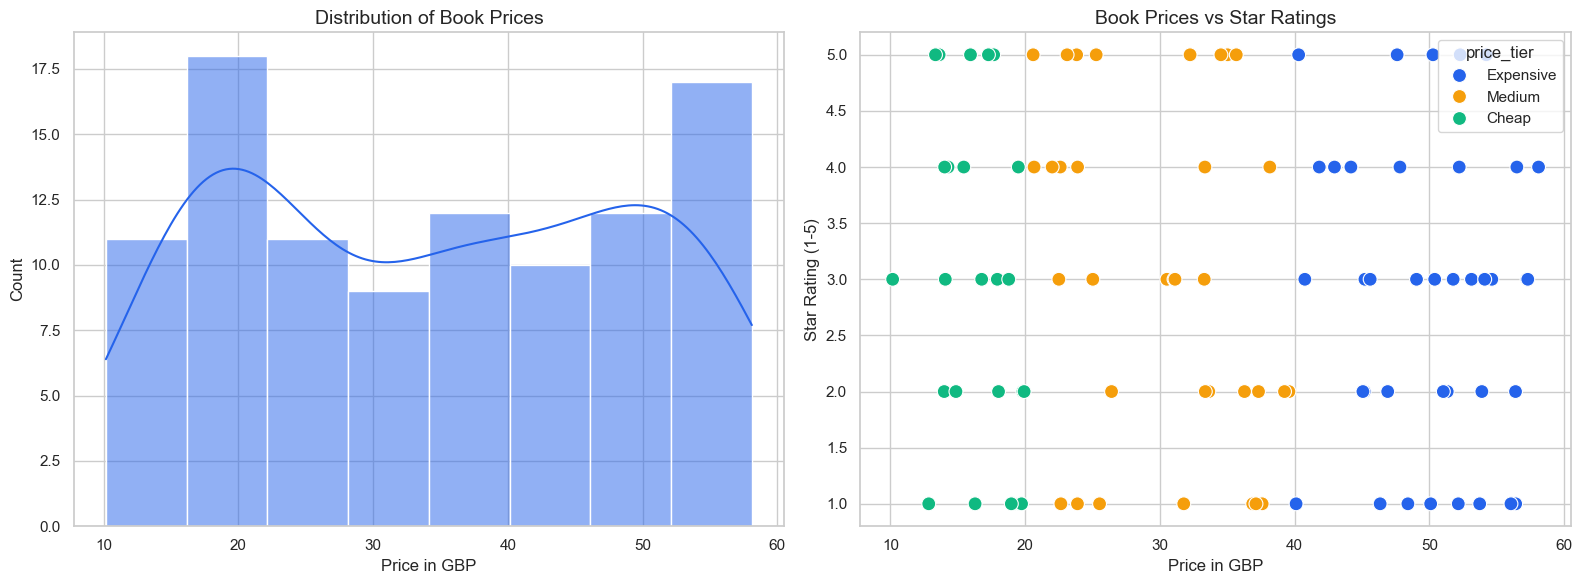

In [10]:
# Force inline notebook plotting
%matplotlib inline

# Set aesthetic theme
sns.set_theme(style="whitegrid")

# Compute data mining insights
pattern_summary = compute_mining_patterns(df_books_transformed)
print("Data Patterns by Price Tier:")
print(pattern_summary)

# Generate analytical charts
plot_price_distributions(df_books_transformed, PALETTE)

In [11]:
import json

def deploy_storage_pipeline(dataframe, summary_df, output_path):
    # Create file destinations
    csv_filename = os.path.join(output_path, "scraped_books_data.csv")
    json_filename = os.path.join(output_path, "books_pipeline_summary.json")

    # Save transformed dataframe
    dataframe.to_csv(csv_filename, index=False)

    # Convert summary to dictionary
    summary_dict = summary_df.to_dict(orient="records")

    # Add metadata attributes
    final_report = {
        "execution_time": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        "total_records": len(dataframe),
        "tier_analysis": summary_dict
    }

    # Save json summary report
    with open(json_filename, "w", encoding="utf-8") as f:
        json.dump(final_report, f, indent=4)

    print("Storage pipeline deployment completed successfully")

# Execute final deployment function
deploy_storage_pipeline(df_books_transformed, pattern_summary, OUTPUT_DIR)

Storage pipeline deployment completed successfully
